<a href="https://colab.research.google.com/github/ahmedsalama07/HR-Analytics-Job-Change-Prediction/blob/main/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [ ]:
df=pd.read_csv("/content/aug_train.csv")

In [ ]:
df.head(10)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0
5,21651,city_176,0.764,NaN,Has relevent experience,Part time course,Graduate,STEM,11,NaN,NaN,1,24,1.0
6,28806,city_160,0.920,Male,Has relevent experience,no_enrollment,High School,NaN,5,50-99,Funded Startup,1,24,0.0
7,402,city_46,0.762,Male,Has relevent experience,no_enrollment,Graduate,STEM,13,<10,Pvt Ltd,>4,18,1.0
8,27107,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,7,50-99,Pvt Ltd,1,46,1.0
9,699,city_103,0.920,NaN,Has relevent experience,no_enrollment,Graduate,STEM,17,10000+,Pvt Ltd,>4,123,0.0


In [ ]:
df.shape

(19158, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [ ]:
df.isnull().sum()

,0
enrollee_id,0
city,0
city_development_index,0
gender,4508
relevent_experience,0
enrolled_university,386
education_level,460
major_discipline,2813
experience,65
company_size,5938


In [ ]:
df['enrollee_id'].value_counts()

,count
enrollee_id,
23834,1
8949,1
29725,1
11561,1
33241,1
...,...
29452,1
699,1
27107,1


In [ ]:
df["gender"].value_counts()

,count
gender,
Male,13221
Female,1238
Other,191


In [ ]:
df["relevent_experience"].value_counts()

,count
relevent_experience,
Has relevent experience,13792
No relevent experience,5366


In [ ]:
df["enrolled_university"].value_counts()

,count
enrolled_university,
no_enrollment,13817
Full time course,3757
Part time course,1198


In [ ]:
df["education_level"].value_counts()

,count
education_level,
Graduate,11598
Masters,4361
High School,2017
Phd,414
Primary School,308


In [ ]:
df["major_discipline"].value_counts()

,count
major_discipline,
STEM,14492
Humanities,669
Other,381
Business Degree,327
Arts,253
No Major,223


In [ ]:
df["experience"].value_counts()

,count
experience,
>20,3286
5,1430
4,1403
3,1354
6,1216
2,1127
7,1028
10,985
9,980


In [ ]:
df["company_size"].value_counts()

,count
company_size,
50-99,3083
100-500,2571
10000+,2019
10/49,1471
1000-4999,1328
<10,1308
500-999,877
5000-9999,563


In [ ]:
df["company_type"].value_counts()

,count
company_type,
Pvt Ltd,9817
Funded Startup,1001
Public Sector,955
Early Stage Startup,603
NGO,521
Other,121


In [ ]:
df["last_new_job"].value_counts()

,count
last_new_job,
1,8040
>4,3290
2,2900
never,2452
4,1029
3,1024


In [ ]:
df["city"].value_counts()

,count
city,
city_103,4355
city_21,2702
city_16,1533
city_114,1336
city_160,845
...,...
city_111,3
city_129,3
city_121,3


In [ ]:
df["target"].value_counts()

,count
target,
0.0,14381
1.0,4777


In [ ]:
df["gender"] = df["gender"].fillna(df["gender"].mode()[0])

df["gender"].isna().sum()

df["gender"].value_counts()

,count
gender,
Male,17729
Female,1238
Other,191


In [ ]:
df["enrolled_university"] = df["enrolled_university"].fillna(df["enrolled_university"].mode()[0])

df["enrolled_university"].isna().sum()

df["enrolled_university"].value_counts()

,count
enrolled_university,
no_enrollment,14203
Full time course,3757
Part time course,1198


In [ ]:
df["education_level"] = df["education_level"].fillna(df["education_level"].mode()[0])

df["education_level"].isna().sum()

df["education_level"].value_counts()

,count
education_level,
Graduate,12058
Masters,4361
High School,2017
Phd,414
Primary School,308


In [ ]:
df["major_discipline"] = df["major_discipline"].fillna(df["major_discipline"].mode()[0])

df["major_discipline"].isna().sum()

df["major_discipline"].value_counts()

,count
major_discipline,
STEM,17305
Humanities,669
Other,381
Business Degree,327
Arts,253
No Major,223


In [ ]:
df["experience"] = df["experience"].fillna(df["experience"].mode()[0])

df["experience"].isna().sum()

df["experience"].value_counts()

,count
experience,
>20,3351
5,1430
4,1403
3,1354
6,1216
2,1127
7,1028
10,985
9,980


In [ ]:
df["company_size"] = df["company_size"].fillna(df["company_size"].mode()[0])

df["company_size"].isna().sum()

df["company_size"].value_counts()

,count
company_size,
50-99,9021
100-500,2571
10000+,2019
10/49,1471
1000-4999,1328
<10,1308
500-999,877
5000-9999,563


In [ ]:
df["company_type"] = df["company_type"].fillna(df["company_type"].mode()[0])

df["company_type"].isna().sum()

df["company_type"].value_counts()

,count
company_type,
Pvt Ltd,15957
Funded Startup,1001
Public Sector,955
Early Stage Startup,603
NGO,521
Other,121


In [ ]:
df["last_new_job"] = df["last_new_job"].fillna(df["last_new_job"].mode()[0])

df["last_new_job"].isna().sum()

df["last_new_job"].value_counts()

,count
last_new_job,
1,8463
>4,3290
2,2900
never,2452
4,1029
3,1024


In [ ]:
df.isna().sum()

,0
enrollee_id,0
city,0
city_development_index,0
gender,0
relevent_experience,0
enrolled_university,0
education_level,0
major_discipline,0
experience,0
company_size,0


In [ ]:
df.duplicated().sum()

df.drop_duplicates(inplace=True)
df = df.drop(columns=["enrollee_id"])

df.duplicated().sum()

np.int64(97)

Feature Engineering

In [ ]:
df["experience"] = df["experience"].replace({
    "<1":0,
    ">20":21
})

df["experience"] = df["experience"].astype(int)

df["last_new_job"] = df["last_new_job"].replace({
    "never":0,
    ">4":5
})

df["last_new_job"] = df["last_new_job"].astype(int)

Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

le = LabelEncoder()

df_encoded["target"] = le.fit_transform(df_encoded["target"])

One Hot Encoding

In [ ]:
categorical_cols = df_encoded.select_dtypes(include="object").columns.tolist()

df_encoded = pd.get_dummies(
    df_encoded,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

df_encoded.head()

,city_development_index,experience,last_new_job,training_hours,target,city_city_10,city_city_100,city_city_101,city_city_102,city_city_103,...,company_size_10000+,company_size_50-99,company_size_500-999,company_size_5000-9999,company_size_<10,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd
0,0.920,21,1,36,1,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,1
1,0.776,15,5,47,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
2,0.624,5,0,83,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
3,0.789,0,0,52,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
4,0.767,21,4,8,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0


In [ ]:
print(categorical_cols)

['city', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'company_size', 'company_type']


Correlation

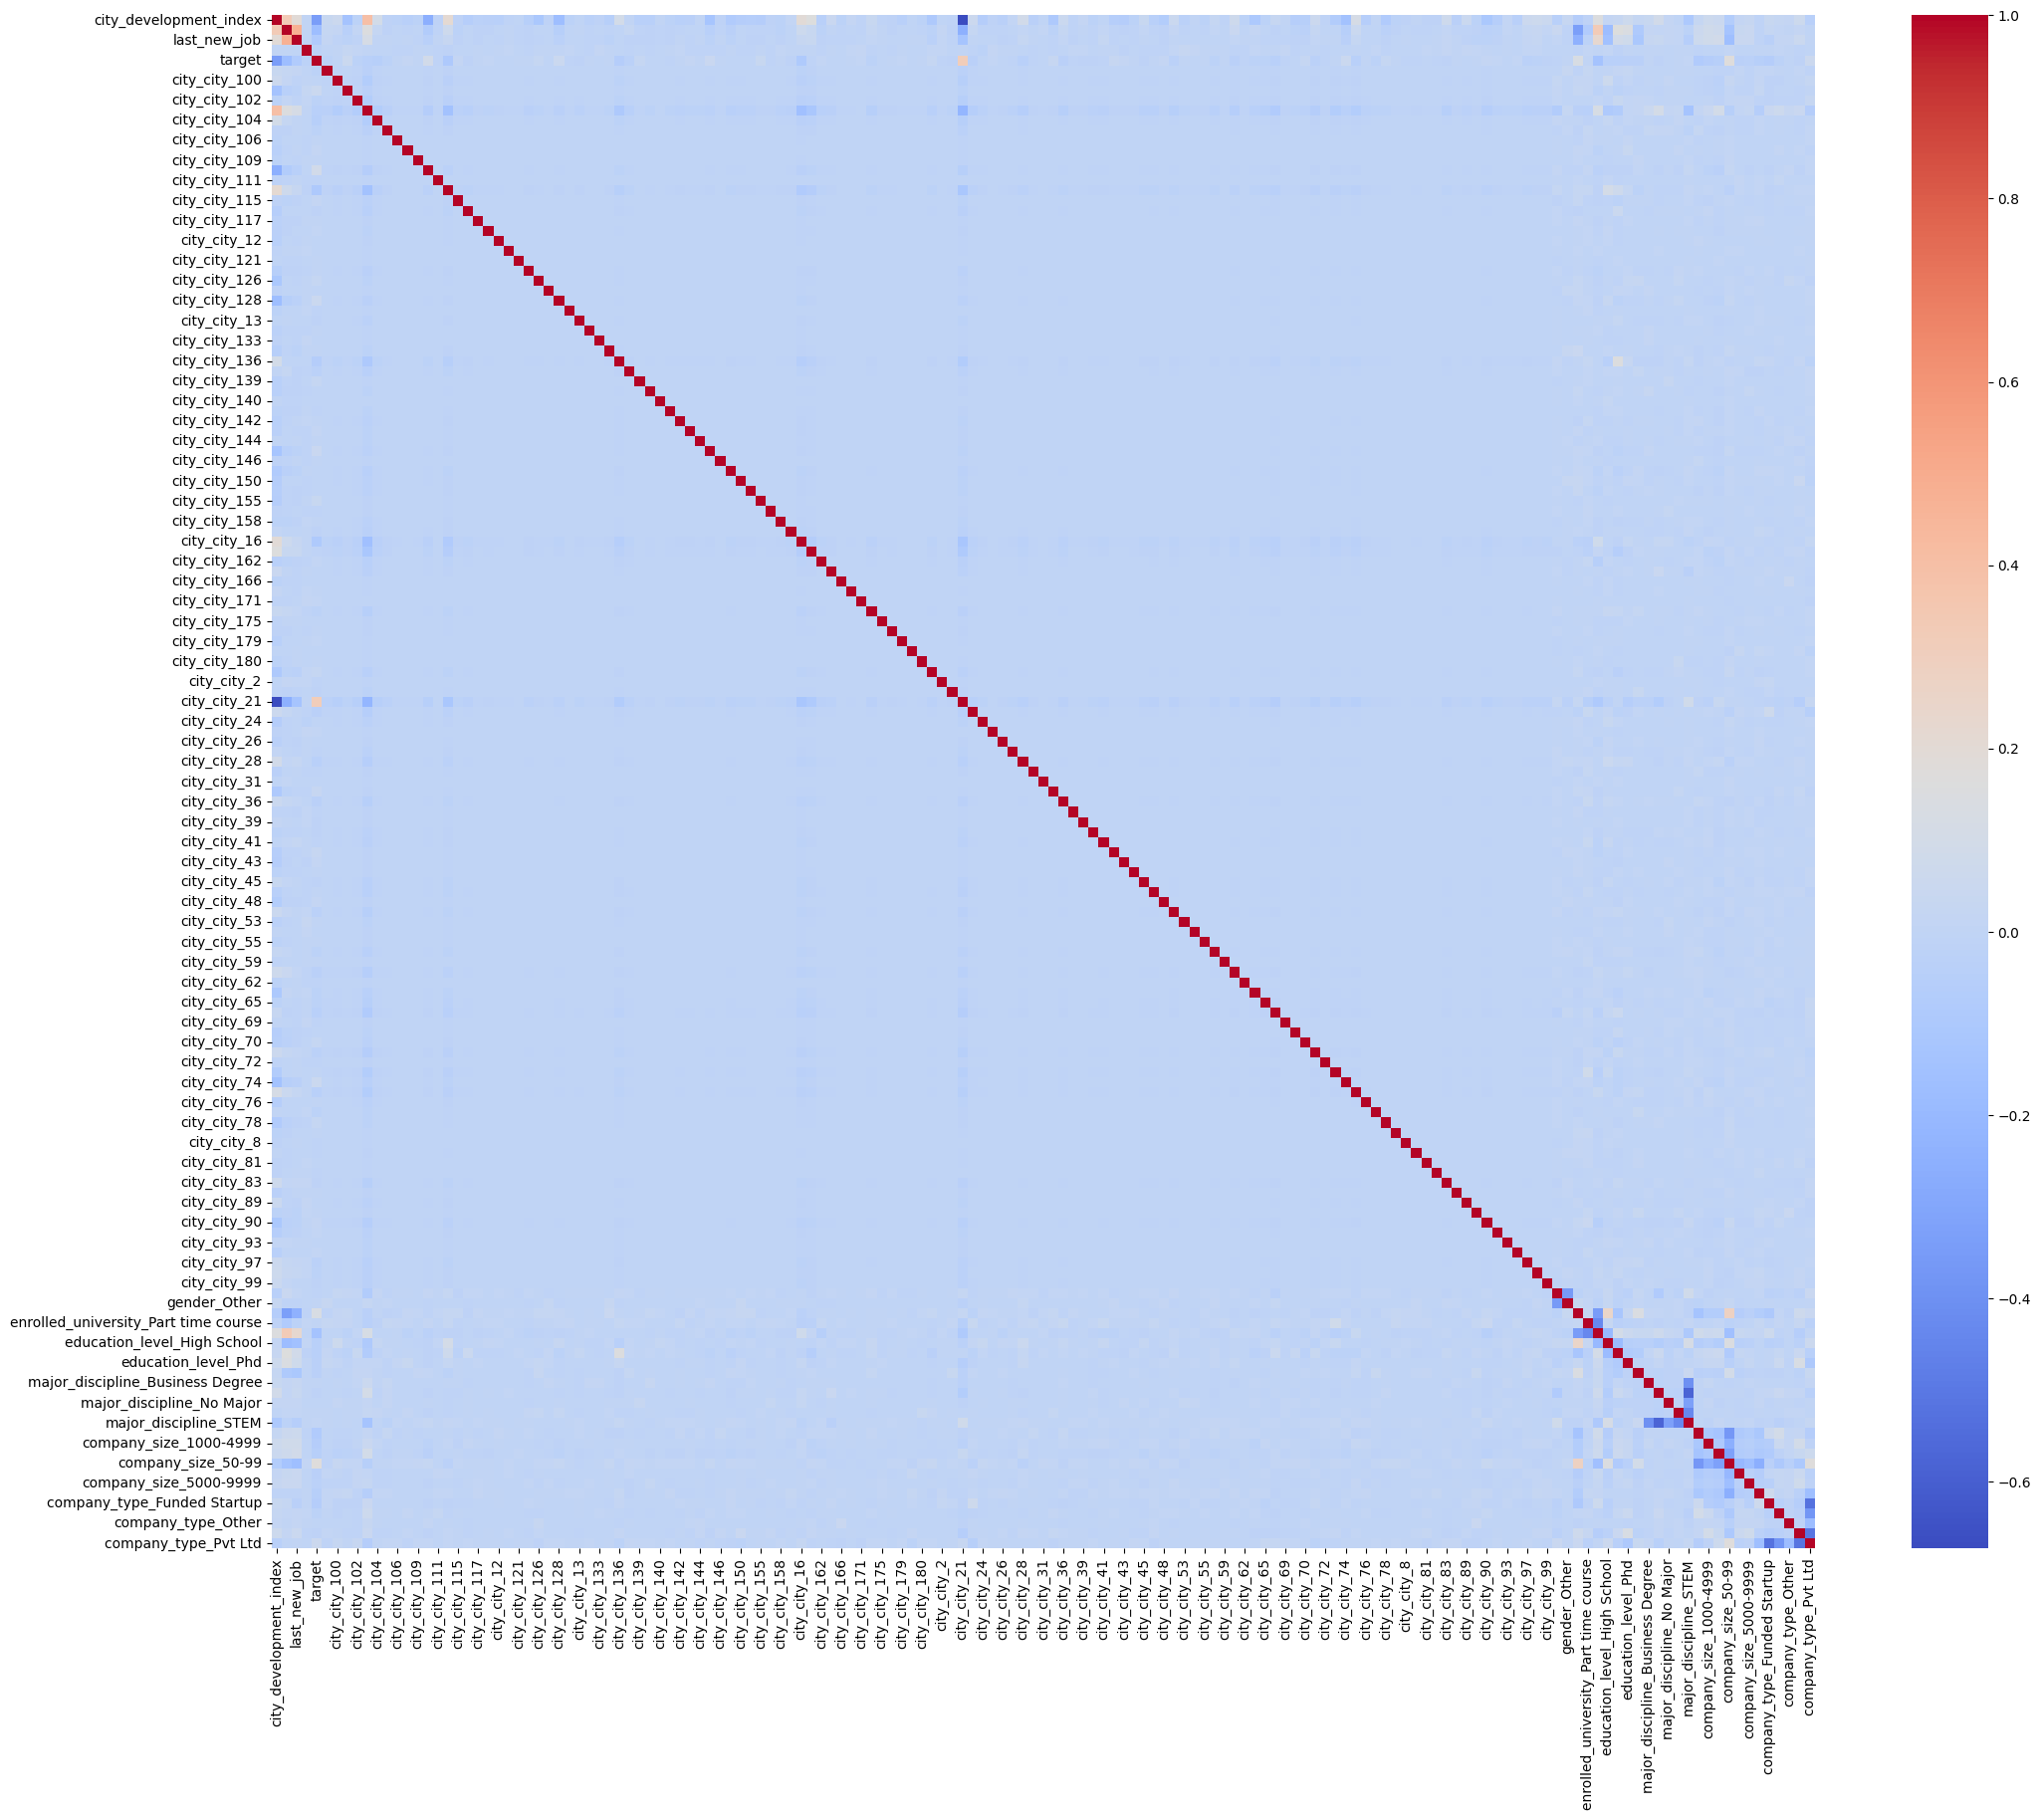

In [ ]:
corr_matrix = df_encoded.corr()

plt.figure(figsize=(25,20))
sns.heatmap(corr_matrix,cmap="coolwarm")
plt.show()

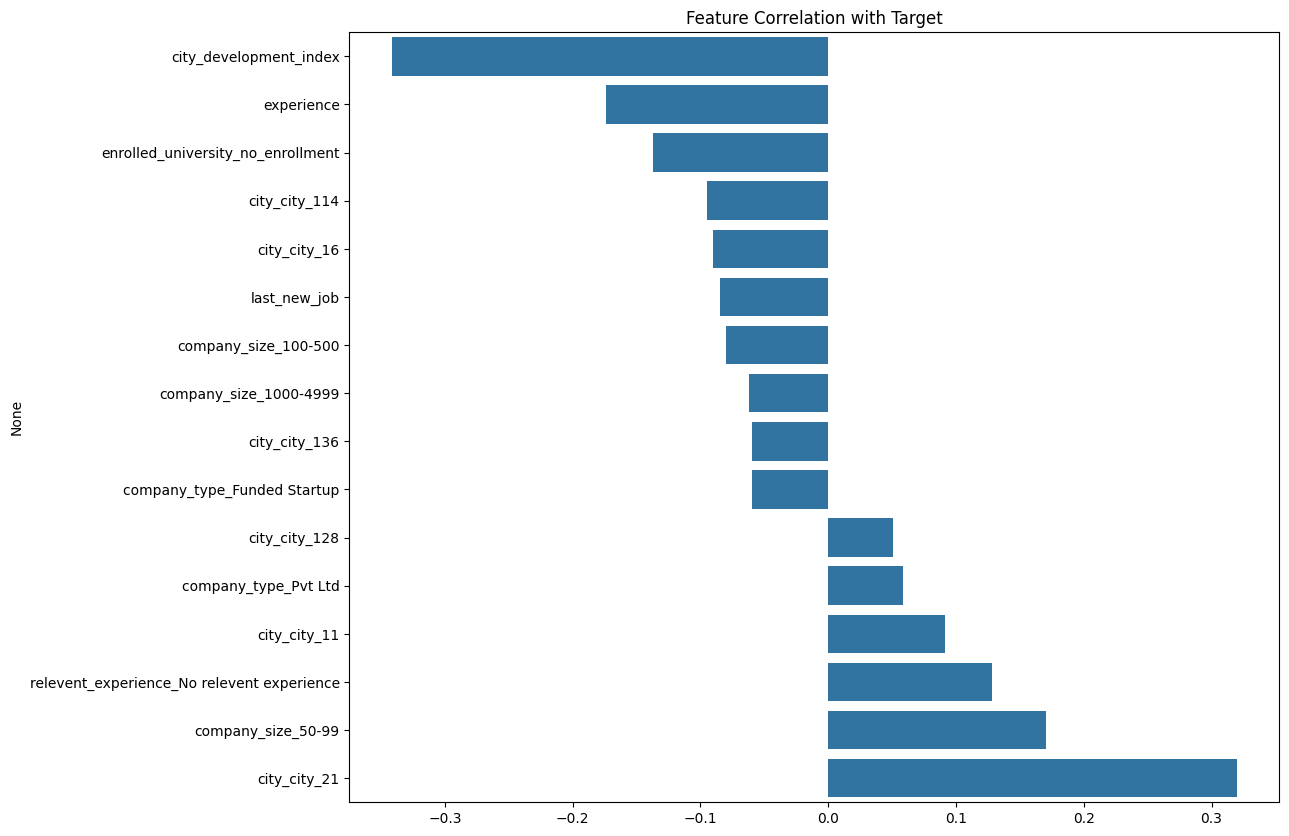

In [ ]:
target_corr = df_encoded.corr()["target"].drop("target")

relevant_features = target_corr[target_corr.abs()>0.05].sort_values()

plt.figure(figsize=(12,10))

sns.barplot(
    x=relevant_features.values,
    y=relevant_features.index
)

plt.title("Feature Correlation with Target")

plt.show()

Train Test Split

In [ ]:
X = df_encoded.drop("target",axis=1)

y = df_encoded["target"]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Standardization

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Logistic Regression

In [ ]:
model1 = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model1.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

Evaluation

In [ ]:
y_pred = model1.predict(X_test)

print("Accuracy :",accuracy_score(y_test,y_pred))

print(confusion_matrix(y_test,y_pred))

print(classification_report(y_test,y_pred))

Accuracy : 0.7413883089770354
[[2128  749]
 [ 242  713]]
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      2877
           1       0.49      0.75      0.59       955

    accuracy                           0.74      3832
   macro avg       0.69      0.74      0.70      3832
weighted avg       0.80      0.74      0.76      3832



Random Forest

In [ ]:
model2 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model2.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

Evaluation

In [ ]:
y_pred = model2.predict(X_test)

print("Accuracy :",accuracy_score(y_test,y_pred))

print(confusion_matrix(y_test,y_pred))

print(classification_report(y_test,y_pred))

Accuracy : 0.7703549060542797
[[2558  319]
 [ 561  394]]
              precision    recall  f1-score   support

           0       0.82      0.89      0.85      2877
           1       0.55      0.41      0.47       955

    accuracy                           0.77      3832
   macro avg       0.69      0.65      0.66      3832
weighted avg       0.75      0.77      0.76      3832



Gradient Boosting

In [ ]:
model3 = GradientBoostingClassifier(random_state=42)

model3.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

Evaluation

In [ ]:
y_pred = model3.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy : 0.7847077244258872
[[2576  301]
 [ 524  431]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      2877
           1       0.59      0.45      0.51       955

    accuracy                           0.78      3832
   macro avg       0.71      0.67      0.69      3832
weighted avg       0.77      0.78      0.77      3832



XGBoost

In [ ]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

In [ ]:
model4 = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=neg/pos
)

model4.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

Evaluation

In [ ]:
y_pred = model4.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy : 0.7518267223382046
[[2170  707]
 [ 244  711]]
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      2877
           1       0.50      0.74      0.60       955

    accuracy                           0.75      3832
   macro avg       0.70      0.75      0.71      3832
weighted avg       0.80      0.75      0.77      3832



In [ ]:
models = {
    "Logistic Regression": model1,
    "Random Forest": model2,
    "Gradient Boosting": model3,
    "XGBoost": model4
}

results = []

for name, model in models.items():

    pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred)
    })

results = pd.DataFrame(results)

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1
2,Gradient Boosting,0.784708,0.588798,0.451309,0.510966
1,Random Forest,0.770355,0.552595,0.412565,0.472422
3,XGBoost,0.751827,0.501410,0.744503,0.599241
0,Logistic Regression,0.741388,0.487688,0.746597,0.589988


Feature Importance

In [ ]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":model2.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
3,training_hours,0.228873
1,experience,0.139890
0,city_development_index,0.116925
2,last_new_job,0.069026
67,city_city_21,0.042428
143,company_size_50-99,0.035971
128,relevent_experience_No relevent experience,0.022556
130,enrolled_university_no_enrollment,0.021556
132,education_level_Masters,0.019287
131,education_level_High School,0.014616


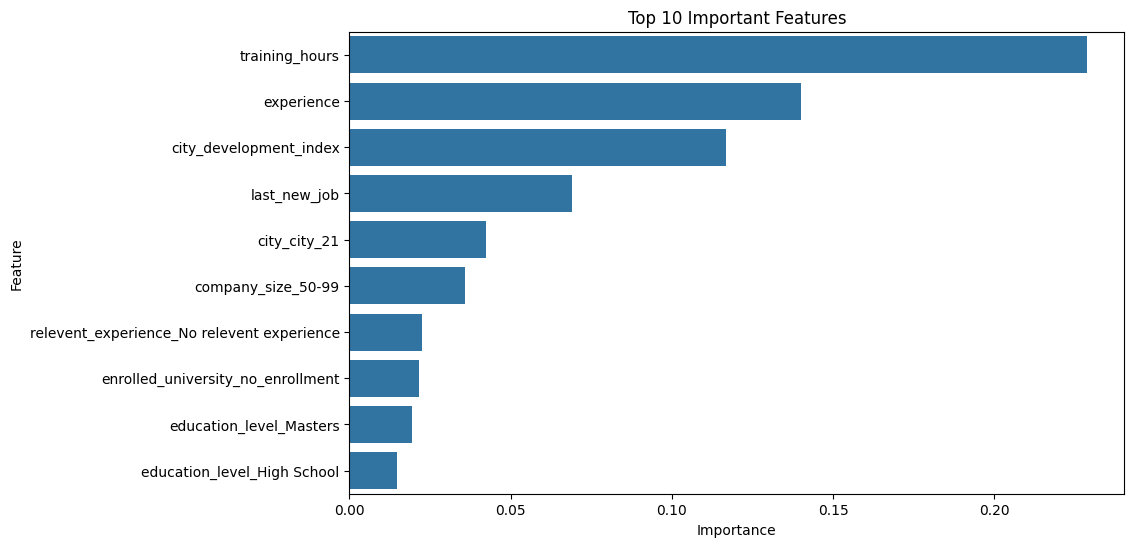

In [ ]:
top10 = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top10
)

plt.title("Top 10 Important Features")

plt.show()

**Models with important features**

Gradient boosting

In [ ]:
important_features = [
    'training_hours',
    'experience',
    'city_development_index',
    'last_new_job',
    'city_city_21',
    'company_size_50-99',
    'relevent_experience_No relevent experience',
    'enrolled_university_no_enrollment',
    'education_level_Masters',
    'education_level_High School'
]

X_important = X[important_features]

X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_important,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler_imp = StandardScaler()
X_train_imp_scaled = scaler_imp.fit_transform(X_train_imp)
X_test_imp_scaled = scaler_imp.transform(X_test_imp)

model_gb_imp = GradientBoostingClassifier(random_state=42)
model_gb_imp.fit(X_train_imp_scaled, y_train_imp)

y_pred_gb_imp = model_gb_imp.predict(X_test_imp_scaled)

print("Accuracy :", accuracy_score(y_test_imp, y_pred_gb_imp))
print("Classification Report :\n", classification_report(y_test_imp, y_pred_gb_imp))

Accuracy : 0.7847077244258872
Classification Report :
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      2877
           1       0.59      0.46      0.51       955

    accuracy                           0.78      3832
   macro avg       0.71      0.68      0.69      3832
weighted avg       0.77      0.78      0.78      3832



Logistic Regression

In [ ]:
model_lr_imp = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
model_lr_imp.fit(X_train_imp_scaled, y_train_imp)

y_pred_lr_imp = model_lr_imp.predict(X_test_imp_scaled)

print("Accuracy  :", accuracy_score(y_test_imp, y_pred_lr_imp))
print("Classification Report :\n", classification_report(y_test_imp, y_pred_lr_imp))

Accuracy  : 0.7309498956158664
Classification Report :
               precision    recall  f1-score   support

           0       0.88      0.74      0.80      2877
           1       0.47      0.71      0.57       955

    accuracy                           0.73      3832
   macro avg       0.68      0.72      0.69      3832
weighted avg       0.78      0.73      0.75      3832



Random Forest

In [ ]:
model_rf_imp = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)
model_rf_imp.fit(X_train_imp_scaled, y_train_imp)

y_pred_rf_imp = model_rf_imp.predict(X_test_imp_scaled)

print("Accuracy :", accuracy_score(y_test_imp, y_pred_rf_imp))
print("Classification Report :\n", classification_report(y_test_imp, y_pred_rf_imp))

Accuracy : 0.7617432150313153
Classification Report :
               precision    recall  f1-score   support

           0       0.81      0.89      0.85      2877
           1       0.53      0.39      0.45       955

    accuracy                           0.76      3832
   macro avg       0.67      0.64      0.65      3832
weighted avg       0.74      0.76      0.75      3832



XGBoost

In [ ]:
neg_imp = (y_train_imp == 0).sum()
pos_imp = (y_train_imp == 1).sum()

model_xgb_imp = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=neg_imp/pos_imp
)
model_xgb_imp.fit(X_train_imp_scaled, y_train_imp)

y_pred_xgb_imp = model_xgb_imp.predict(X_test_imp_scaled)

print("Accuracy :", accuracy_score(y_test_imp, y_pred_xgb_imp))
print("Classification Report  :\n", classification_report(y_test_imp, y_pred_xgb_imp))

Accuracy : 0.7479123173277662
Classification Report  :
               precision    recall  f1-score   support

           0       0.88      0.77      0.82      2877
           1       0.50      0.69      0.58       955

    accuracy                           0.75      3832
   macro avg       0.69      0.73      0.70      3832
weighted avg       0.79      0.75      0.76      3832

